<a href="https://colab.research.google.com/github/seanperdomo/Proyecto_2_MD/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Disección de un Campo Profundo Multi-Longitud de Onda** - Proyecto 2 - Minería de Datos
### **Por:**

*   Soleil Dayana Niño Murcia
*   Sean Paul Perdomo

### **Problema Astrofísico:**

Los astrónomos modernos no observan un solo objeto; apuntan sus telescopios a un “Campo Profundo” (un parche de cielo) y extraen todo lo que hay en él utilizando diferentes longitudes de onda.

En este trabajo se analiza el campo ecuatorial centrado en las coordenadas RA: 135.5, Dec: 0.5 (con un radio de 0.5 grados). Al cartografiar esta región para separar las estrellas locales de nuestra galaxia y aislar las galaxias lejanas, se podrá descubrir cuásares enrojecidos por el polvo. Para lograrlo, se combinará astrometría, espectroscopía y fotometría óptica e infrarroja.

## Configuración Python

Librerias:

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Misión A: El Cartógrafo Galáctico (VizieR)**

Se realiza una consulta en bash a VizieR, haciendo un cruce espacial masivo (un LEFT JOIN con un radio de 2 arcosegundos) entre la base de datos de Gaia DR3 (astrometría óptica) y AllWISE (fotometría infrarroja). Se extraen el paralaje, los movimientos propios y las magnitudes principales (Gmag, W1mag) de todos los objetos en el campo profundo especificado.

## Query y descarga de datos

In [6]:
%%bash

QUERY="SELECT+TOP+5000+g.Gmag,g.Plx,g.PMRA,g.PMDE,w.W1mag+FROM+\"I/355/gaiadr3\"+AS+g+INNER+JOIN+\"II/328/allwise\"+AS+w+ON+1=CONTAINS(POINT('ICRS',w.RAJ2000,w.DEJ2000),CIRCLE('ICRS',g.RA_ICRS,g.DE_ICRS, 0.00056))+WHERE+1=CONTAINS(POINT('ICRS',w.RAJ2000,w.DEJ2000),CIRCLE('ICRS',135.5,0.5,0.5))+AND+1=CONTAINS(POINT('ICRS',g.RA_ICRS,g.DE_ICRS),CIRCLE('ICRS',135.5,0.5,0.5))"
TAP="https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync?request=doQuery&lang=ADQL&format=csv&query="
URL="${TAP}${QUERY}"
URL_CLEAN=$(echo $URL | sed 's\ \+\g')

wget -q -O mag_y_par.csv "$URL_CLEAN"

Limpieza del dataframe:

In [7]:
df = pd.read_csv("mag_y_par.csv").dropna()
df

,Gmag,Plx,pmRA,pmDE,W1mag
0,20.026037,5.6234,-4.673,-4.926,15.817
1,15.976371,6.3935,37.901,-70.548,12.282
2,16.363176,0.7983,0.717,-2.661,14.528
3,16.236700,0.4631,-5.962,-2.177,14.872
4,18.048435,0.3126,-3.634,2.585,16.118
...,...,...,...,...,...
3787,16.182987,1.2489,-11.382,5.447,13.635
3788,16.697906,0.3429,-1.637,-0.220,15.266
3789,18.231508,-0.0996,-1.470,0.442,16.806
3790,19.139265,0.6747,-10.229,5.447,15.698


Se considera 15kpc como el radio galáctico, lo que es equivalente a un paralaje 1/15 milisegundos de arco. El paralaje proporcionado por Vizier está en milisegundos de arco, por lo que no es necesario realizar la conversión.

In [8]:
df = df[df['Plx'] > 1/15] # Estrellas dentro de la galaxia
df

,Gmag,Plx,pmRA,pmDE,W1mag
0,20.026037,5.6234,-4.673,-4.926,15.817
1,15.976371,6.3935,37.901,-70.548,12.282
2,16.363176,0.7983,0.717,-2.661,14.528
3,16.236700,0.4631,-5.962,-2.177,14.872
4,18.048435,0.3126,-3.634,2.585,16.118
...,...,...,...,...,...
3786,13.421206,0.9002,-0.593,0.631,12.146
3787,16.182987,1.2489,-11.382,5.447,13.635
3788,16.697906,0.3429,-1.637,-0.220,15.266
3790,19.139265,0.6747,-10.229,5.447,15.698


Se calcula el índice de color:

In [9]:
df['G-W'] = df['Gmag'] - df['W1mag']
df

/tmp/ipykernel_2925/339990965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['G-W'] = df['Gmag'] - df['W1mag']


,Gmag,Plx,pmRA,pmDE,W1mag,G-W
0,20.026037,5.6234,-4.673,-4.926,15.817,4.209037
1,15.976371,6.3935,37.901,-70.548,12.282,3.694371
2,16.363176,0.7983,0.717,-2.661,14.528,1.835176
3,16.236700,0.4631,-5.962,-2.177,14.872,1.364700
4,18.048435,0.3126,-3.634,2.585,16.118,1.930435
...,...,...,...,...,...,...
3786,13.421206,0.9002,-0.593,0.631,12.146,1.275206
3787,16.182987,1.2489,-11.382,5.447,13.635,2.547987
3788,16.697906,0.3429,-1.637,-0.220,15.266,1.431906
3790,19.139265,0.6747,-10.229,5.447,15.698,3.441265


Se grafica el diagrama color-magnitud:

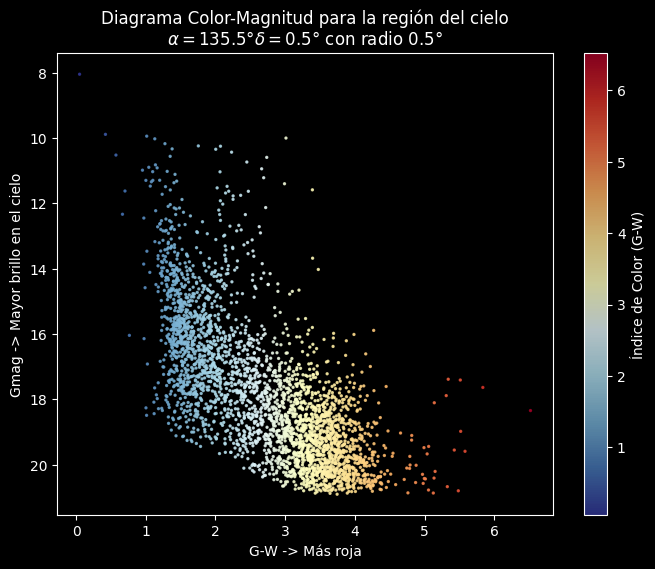

In [21]:
plt.style.use('dark_background')
plt.figure(figsize=(8, 6))
sc = plt.scatter(df['G-W'], df['Gmag'], c=df['G-W'], cmap='RdYlBu_r', s=2, alpha=0.8)
plt.title('Diagrama Color-Magnitud para la región del cielo\n'+ r'$\alpha=135.5$°$\delta=0.5$° con radio 0.5°')
plt.ylabel('Gmag -> Mayor brillo en el cielo')
plt.xlabel('G-W -> Más roja')
cbar = plt.colorbar(sc)
cbar.set_label('Índice de Color (G-W)')
plt.gca().invert_yaxis()
plt.savefig('cmd_1.png')
plt.show()

## Conclusiones Misión A:

* Al observar objetos en el infarrojo y en el óptico a partir de la unión de dos tablas de Vizier, fue posible observar un gran conjunto de estrellas en la región solicitada $\delta = 135$°, $\alpha=0.5$° en un radio de 0.5°. A partir de esto se pueden agrupar datos cinemáticos (como el paralaje y el movimiento propio) con datos astrométricos para identificar aquellas estrellas dentro de la galaxia, cuyo paralaje es mayor a 1/15 mas.

* Con estas estrellas, se logró hacer un diagrama de color magnitud a partir de las bandas fotométricas $G$, correspondiente al visible, y $W1$, correspondiente al infrarrojo. Al realizar el diagrama, es posible identificar una línea gruesa, lo que indica que estamos observando un grupo estelar en el campo de visión mas no un cúmulo en específico. Además, como hay una línea diagonal dominante, esto significa que una gran parte de las estrellas observadas en esta región hacen parte de la secuencia principal.

# Misión B: El Cosmólogo (SDSS & MAST)

## Extracción: Celda de Bash para enviar una consulta SQL al SkyServer de SDSS.
En la consulta se realizará un INNER JOIN entre las tablas de espectroscopía y fotometría. Tomando la clase del objeto (class), el corrimiento al rojo (z) y las magnitudes ultravioleta y verde (u, g), limitando la búsqueda exactamente a las coordenadas trabajadas en la misión A (RA 103.5, DEC 0.5, radio 0.5)


Query:

```
SELECT
    s.specObjID,
    s.class,
    s.z,
    p.objID,
    p.ra,
    p.dec,
    p.u,
    p.g
FROM dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n
JOIN PhotoObj AS p ON p.objID = n.objID
JOIN SpecObj  AS s ON s.bestObjID = p.objID
WHERE p.u > -9999 AND p.g > -9999
```

Notas:
* En SDSS SkyServer no se pone el cono como un WHERE ra BETWEEN manualmente, sino con la función dbo.fGetNearbyObjEq(ra, dec, radio_en_arcmin)

* El radio en esta función va en arcominutos, así que se aplica 0.5° = 30 arcmin.
* Se descartan valores erráticos de -9999

In [22]:
%%bash
TAP_B="https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch?format=csv&cmd="
QUERY_B="SELECT s.specObjID, s.class, s.z, p.objID, p.ra, p.dec, p.u, p.g FROM dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n JOIN PhotoObj AS p ON p.objID = n.objID JOIN SpecObj AS s ON s.bestObjID = p.objID WHERE p.u > -9999 AND p.g > -9999"
URL_B="${TAP_B}${QUERY_B}"
URL_CLEAN_B="${URL_B// /+}"
wget -q -O sdss_campo_profundo.csv "$URL_CLEAN_B"

In [23]:
data_B = pd.read_csv("sdss_campo_profundo.csv", comment='#')
data_B

,specObjID,class,z,objID,ra,dec,u,g
0,14111152446803040256,STAR,0.000816,1237648721747968249,135.118073,0.296950,21.76750,22.00401
1,528051761328449536,QSO,1.904528,1237648721748099313,135.393249,0.352625,19.51237,19.45119
2,4298841792911267840,STAR,0.000142,1237648721748164770,135.645260,0.315857,21.66825,19.96913
3,4296489658299471872,QSO,0.908191,1237648722284773895,135.037864,0.635471,21.37742,20.86644
4,529299707294410752,GALAXY,0.131484,1237648722285166888,135.865254,0.688551,19.46726,18.34731
...,...,...,...,...,...,...,...,...
247,4295575418826938368,STAR,0.000327,1237674461486711476,135.123692,0.469598,22.32479,21.11669
248,4298843442178709504,GALAXY,0.567348,1237674461486908156,135.628627,0.584857,24.09669,23.35610
249,528055059863332864,GALAXY,0.012759,1237674461487039093,135.780954,0.858236,19.08853,17.99867
250,528088869845886976,STAR,0.000560,1237674462023647459,135.081193,0.754912,20.33305,19.89935


Obtener el índice de color $u-g$

In [24]:
# Crear columna de índice de color u - g
data_B['u-g'] = data_B['u'] - data_B['g']
data_B

,specObjID,class,z,objID,ra,dec,u,g,u-g
0,14111152446803040256,STAR,0.000816,1237648721747968249,135.118073,0.296950,21.76750,22.00401,-0.23651
1,528051761328449536,QSO,1.904528,1237648721748099313,135.393249,0.352625,19.51237,19.45119,0.06118
2,4298841792911267840,STAR,0.000142,1237648721748164770,135.645260,0.315857,21.66825,19.96913,1.69912
3,4296489658299471872,QSO,0.908191,1237648722284773895,135.037864,0.635471,21.37742,20.86644,0.51098
4,529299707294410752,GALAXY,0.131484,1237648722285166888,135.865254,0.688551,19.46726,18.34731,1.11995
...,...,...,...,...,...,...,...,...,...
247,4295575418826938368,STAR,0.000327,1237674461486711476,135.123692,0.469598,22.32479,21.11669,1.20810
248,4298843442178709504,GALAXY,0.567348,1237674461486908156,135.628627,0.584857,24.09669,23.35610,0.74059
249,528055059863332864,GALAXY,0.012759,1237674461487039093,135.780954,0.858236,19.08853,17.99867,1.08986
250,528088869845886976,STAR,0.000560,1237674462023647459,135.081193,0.754912,20.33305,19.89935,0.43370


Graficar redshift vs. índice de color (u-g)

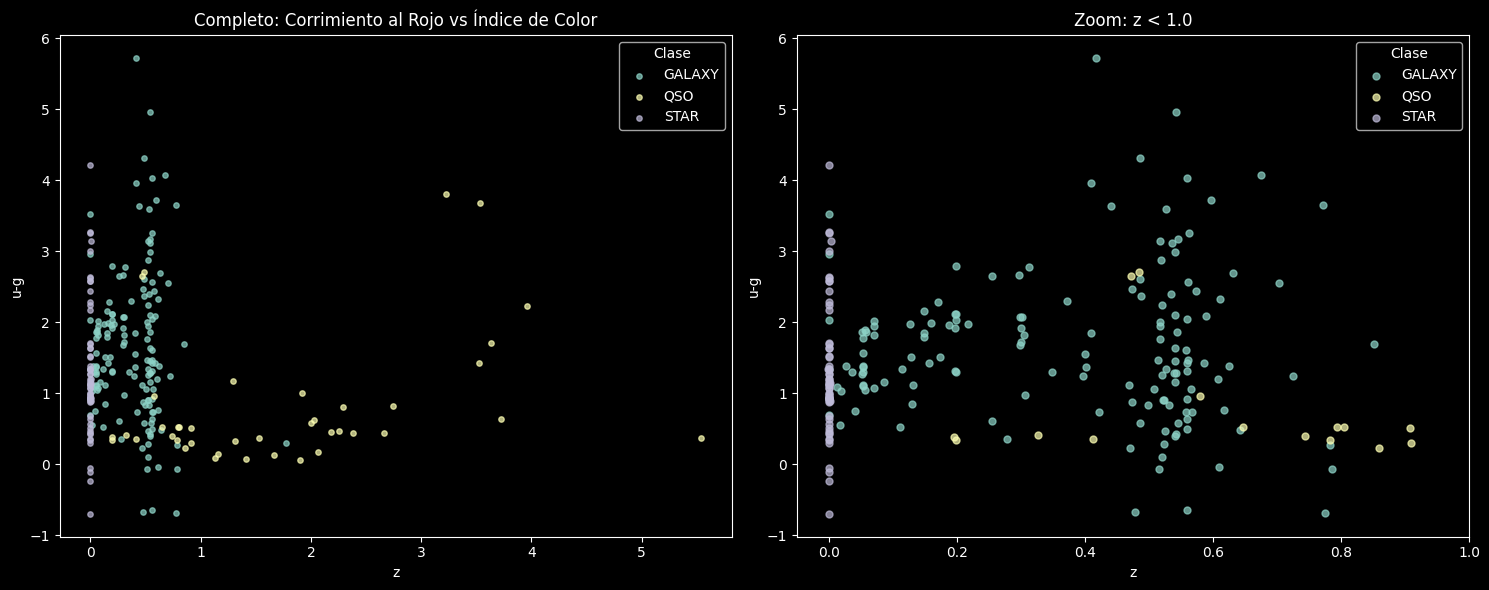

In [26]:
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Panorama completo
for name, group in data_B.groupby('class'):
    ax1.scatter(group['z'], group['u-g'], s=15, alpha=0.7, label=name)
ax1.set_ylabel('u-g')
ax1.set_xlabel('z')
ax1.set_title('Completo: Corrimiento al Rojo vs Índice de Color')
ax1.legend(title='Clase')

# Gráfica 2: Zoom en z < 1
for name, group in data_B.groupby('class'):
    ax2.scatter(group['z'], group['u-g'], s=25, alpha=0.7, label=name)
ax2.set_xlim(-0.05, 1.0)
ax2.set_ylabel('u-g')
ax2.set_xlabel('z')
ax2.set_title('Zoom: z < 1.0')
ax2.legend(title='Clase')

plt.tight_layout()
plt.grid('True')
plt.savefig('cmd_2.png')
plt.show()

### **Análisis y Conclusiones: Corrimiento al Rojo ($z$) vs. Índice de Color ($u-g$)**

Al analizar la relación entre el redshift ($z$) y el índice de color óptico ($u-g$), podemos identidificar de forma clara el comportamiento distintivo de cada una de las trs poblaciones:

1. **Estrellas (STAR - Color lila):**
   * Se agrupan estrictamente en un corrimiento al rojo $z \approx 0$. Esto era lo físicamente esperado, ya que las estrellas observadas pertenecen a nuestra propia galaxia (Vía Láctea) y no experimentan el estiramiento cosmológico del espacio.
   * **Índice de color ($u-g$):** Están dispersadas en una línea vertical amplia (desde $-0.5$ hasta $>4.0$), mostrando la diversidad de temperaturas y tipos espectrales de las estrellas (desde estrellas calientes de tipo O/B hasta enanas frías de tipo M).

2. **Galaxias (GALAXY - Color verde azulado):**
   * Se distribuyen principalmente en el rango de $0 < z < 0.8$.
   * Al observar el gráfico de zoom, se evidencia cómo a mayor redshift las galaxias tienden a mostrar un índice $u-g$ más alto (colores más rojos). Esto se debe tanto al corrimiento al rojo cosmológico (que desplaza el flujo de la galaxia hacia bandas de mayor longitud de onda) como al envejecimiento de las poblaciones estelares que las componen.

3. **Cuásares (QSO - Color amarillo):**
   * Se extienden a lo largo de un rango de redshift mucho mayor, llegando en este campo profundo hasta $z \approx 5.5$.
   * A pesar de encontrarse a distancias cosmológicas extremas, muchos QSOs mantienen índices de color relativamente bajos ($u-g \approx 0.5$), lo que puede ser dado porque su emisión está dominada por el disco de acreción del agujero negro supermasivo central, el cual emite una gran cantidad de radiación ultravioleta térmica altamente energética.

# **Misión Conjunta (Integración y Conclusiones)**



## **La importancia de cruzar el espectro óptico con el infrarrojo para tener una imagen completa del universo**

Las estrellas dentro de la galaxia pueden ir perdiendo su brillo aparente a medida que la luz emitida viaja por el medio interestelar, por lo que conforme aumenta la distancia de observación, el espectro infrarrojo empieza a ser clave, pues es capaz de recopilar información a través de nubes de polvo que de otra forma obstaculizarían el paso de la luz en el óptico. Esto es aún más marcado, al observar objetos de carácter extragaláctico, pues hay todavía más material que atravesar, por lo que el espectro en infrarrojo nos permite observar aquellos objetos que completan el mapa del universo. Es decir, al cruzar ambas bandas fotométricas se tiene una descripción más completa del universo gracias a la nueva información que cada una de las bandas puede proporcionar.



## Cómo se complementan Gaia y SDSS

La forma en que se llevó a cabo el estudio en este trabajo es completa y confiable gracias a que se trabajan dos herramientas que aunque responden preguntas distintas, se confirman mutuamente:
Gaia responde ¿qué tan lejos está y cómo se mueve el objeto?. Al medir el desplazamiento de un objeto en el cielo tanto con el efecto de paralaje como el de movimiento propio en teoría se puede inferir la distancia, y se usan puntos de referencia como por ejemplo los QSOs, ya que para ellos estos valores tienden a cero; entonces si una fuente de luz no se mueve ni muestra paralaje, sabemos que está muy lejos. Sin embargo, el problema es que una galaxia lejana también cumple esto, o una estrella débil y con mediciones ruidosas. Así que Gaia cumple con sugerir que el objeto está lo suficientemente lejos, pero no es capaz de clasificarlo.
Por otro lado, el SDSS da información sobre la composición y qué tan lejos está realmente. Al descomponer la luz en el espectro, cada tipo deja una huella diferente. Una estrella muestra líneas de absorción según su composición, y con un corrimiento al rojo prácticamente nulo. Un QSO muestra líneas de emisión muy anchas y desplazadas al rojo, producidas por gas que gira a altas velocidades alrededor de su núcleo, un agujero negro supermasivo. Ese desplazamiento es una medida directa de cuánto se ha expandido el universo mientras la luz viajaba y así, se halla también el tiempo de viaje.
Finalmente, emplear la información de ambas herramientas en conjunto permite confirmar mutuamente lo observado. Por ejemplo para confirmar QSOs, se espera que Gaia no detecte paralaje ni movimiento y SDSS muestre líneas anchas con z alto. Para una estrella, se espera lo contrario, que Gaia mida paralaje y movimiento claros, a la par de que SDSS clasifique z tendiendo a cero. Cuando la prueba de una de las dos herramientas sea ambigua, la otra desempata.